# Job Market Analyzer

## Project Goal

Analyze job posting data to identify:

- Most common job titles
- Top hiring departments
- Remote work trends
- Geographic hiring patterns
- Hiring activity over time

Dataset contains thousands of job postings collected from online job boards.

## Import Libraries

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Data

Load the parquet file and inspect the  structure.

In [124]:
df = pd.read_parquet("../data/part-5.parquet")
df.head()

,id,job_id,company_id,title,department,employment_type,workplace_type,country,is_remote,posted_at,apply_url,entire_json,job_model_json,fetched_time,status,close_time
0,ashbyhq:finni-health/2333cf4b-7c66-4900-bf68-4...,2333cf4b-7c66-4900-bf68-40591b0e311c,39107,Behavior Technician (RBT),Clinical,PartTime,onsite,United States,False,2026-06-12 14:55:57.678000+00:00,https://jobs.ashbyhq.com/finni-health/2333cf4b...,"{""address"":{""postalAddress"":{""addressCountry"":...","{""apply_url"":""https://jobs.ashbyhq.com/finni-h...",2026-06-13 03:34:57.839407+00:00,active,NaT
1,ashbyhq:finni-health/2c255da4-d8b4-4a3f-9a4e-2...,2c255da4-d8b4-4a3f-9a4e-2653f601ea6d,39107,Registered Behavior Technician (RBT),Clinical,PartTime,onsite,United States,False,2026-05-11 18:26:26.457000+00:00,https://jobs.ashbyhq.com/finni-health/2c255da4...,"""{\""address\"": {\""postalAddress\"": {\""addressC...","""{\""apply_url\"": \""https://jobs.ashbyhq.com/fi...",2026-05-24 05:21:11.732242+00:00,closed,2026-06-13 03:34:57.839407+00:00
2,ashbyhq:finni-health/46724ced-4d9a-4750-9fb7-9...,46724ced-4d9a-4750-9fb7-905a3cd0e3c0,39107,Registered Behavior Technician (RBT) - Salt La...,Clinical,FullTime,onsite,United States,False,2026-02-23 17:58:50.973000+00:00,https://jobs.ashbyhq.com/finni-health/46724ced...,"""{\""address\"": {\""postalAddress\"": {\""addressC...","""{\""apply_url\"": \""https://jobs.ashbyhq.com/fi...",2026-05-24 05:21:11.732242+00:00,closed,2026-06-13 03:34:57.839407+00:00
3,ashbyhq:finni-health/4fbde1b3-1c40-4945-98ad-9...,4fbde1b3-1c40-4945-98ad-9ff4761fd2bd,39107,Registered Behavior Technician (RBT),Clinical,FullTime,onsite,United States,False,2026-06-01 17:56:30.715000+00:00,https://jobs.ashbyhq.com/finni-health/4fbde1b3...,"{""address"":{""postalAddress"":{""addressCountry"":...","{""apply_url"":""https://jobs.ashbyhq.com/finni-h...",2026-06-02 02:02:23.025914+00:00,closed,2026-06-13 03:34:57.839407+00:00
4,ashbyhq:finni-health/6b345b1d-d8ec-4f15-bcd1-6...,6b345b1d-d8ec-4f15-bcd1-6efb3308089b,39107,Revenue Cycle Claims Specialist,Operations,FullTime,remote,United States,True,2026-06-03 22:36:43.452000+00:00,https://jobs.ashbyhq.com/finni-health/6b345b1d...,"{""address"":{""postalAddress"":{""addressCountry"":...","{""apply_url"":""https://jobs.ashbyhq.com/finni-h...",2026-06-04 01:47:05.905729+00:00,closed,2026-06-13 03:34:57.839407+00:00


## Initial Exploration

Review columns, data types, and missing values.

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67216 entries, 0 to 67215
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   id               67216 non-null  object             
 1   job_id           67216 non-null  object             
 2   company_id       67216 non-null  int32              
 3   title            67216 non-null  object             
 4   department       25735 non-null  object             
 5   employment_type  56569 non-null  object             
 6   workplace_type   67216 non-null  object             
 7   country          66812 non-null  object             
 8   is_remote        67216 non-null  bool               
 9   posted_at        57752 non-null  datetime64[us, UTC]
 10  apply_url        66811 non-null  object             
 11  entire_json      67216 non-null  object             
 12  job_model_json   67216 non-null  object             
 13  fetched_time    

In [126]:
df.columns.tolist()

['id',
 'job_id',
 'company_id',
 'title',
 'department',
 'employment_type',
 'workplace_type',
 'country',
 'is_remote',
 'posted_at',
 'apply_url',
 'entire_json',
 'job_model_json',
 'fetched_time',
 'status',
 'close_time']

In [127]:
df.isna().sum().sort_values(ascending=False).head(20)

department         41481
close_time         33200
employment_type    10647
posted_at           9464
apply_url            405
country              404
id                     0
job_id                 0
company_id             0
title                  0
workplace_type         0
is_remote              0
entire_json            0
job_model_json         0
fetched_time           0
status                 0
dtype: int64

## Data Cleaning

Remove unnecessary columns and prepare dates for  analysis.

In [128]:
df = df.drop(columns=[
    "id",
    "company_id",
    "apply_url",
    "entire_json",
    "fetched_time",
    "close_time"
    ])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67216 entries, 0 to 67215
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   job_id           67216 non-null  object             
 1   title            67216 non-null  object             
 2   department       25735 non-null  object             
 3   employment_type  56569 non-null  object             
 4   workplace_type   67216 non-null  object             
 5   country          66812 non-null  object             
 6   is_remote        67216 non-null  bool               
 7   posted_at        57752 non-null  datetime64[us, UTC]
 8   job_model_json   67216 non-null  object             
 9   status           67216 non-null  object             
dtypes: bool(1), datetime64[us, UTC](1), object(8)
memory usage: 4.7+ MB


## Duplicate Records

Identify duplicate job postings

In [129]:
# Remove duplicate rows column

duplicates = df.duplicated(subset=["job_id"]).sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 1987


## Data Processing

Convert posting dates into useful time features.

In [130]:
df["posted_at"] = pd.to_datetime(df["posted_at"])
df["year"] = df["posted_at"].dt.year
df["month"] = df["posted_at"].dt.month
df["weekday"] = df["posted_at"].dt.weekday

## Hiring Trends Over Time

Analyze how job posting activity chamges over time.

In [131]:
jobs_per_month = (
    df.groupby(["year","month"])
      .size()
      .reset_index(name="count")
)

Text(0.5, 1.0, 'Job Postings Over Time')

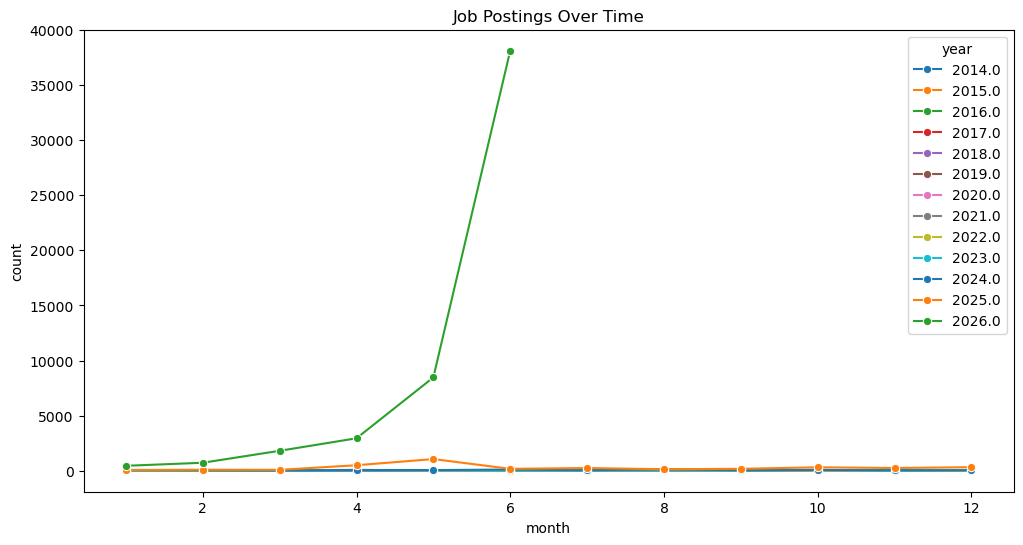

In [132]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=jobs_per_month,
    x="month",
    y="count",
    hue="year",
    palette="tab10",
    marker="o"
)

plt.title("Job Postings Over Time")

## Findings

Hiring activity increased significantly during certain months, suggesting seasonal recruiting patterns.

## Top Job Titles

Identify the most frequently advertised postitons.

In [133]:
top_titles = df['title'].value_counts().head(10)

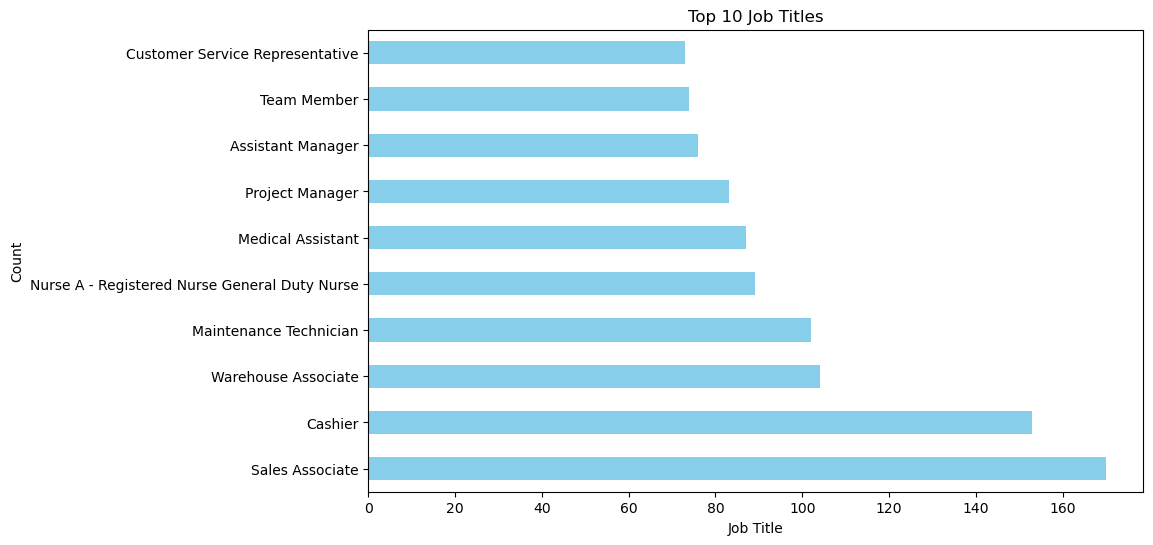

In [134]:
plt.figure(figsize=(10, 6))

top_titles.sort_values(ascending=False).plot(kind='barh', color='skyblue')
plt.title('Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.show()

## Findings

These postitons represent the highest hiring demand within the dataset. 
Based off the graph the top 3 are Sales Associate, Cashier, and Warehouse Associate.

## Hiring by Department

In [135]:
top_departments = df['department'].value_counts().head(10)

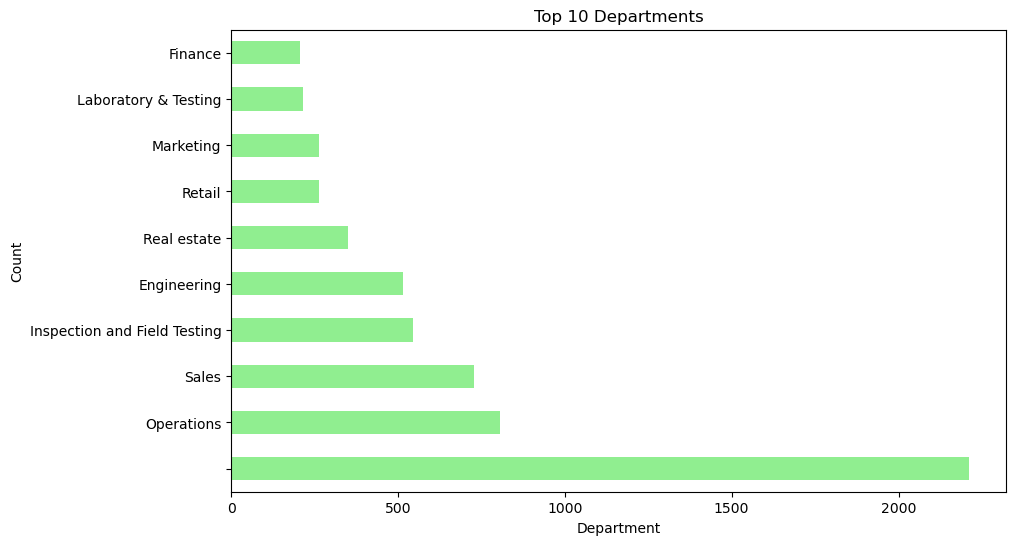

In [136]:
plt.figure(figsize=(10, 6))
top_departments.plot(kind='barh', color='lightgreen')
plt.title('Top 10 Departments')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

## Remote vs Hybrid vs On-Site

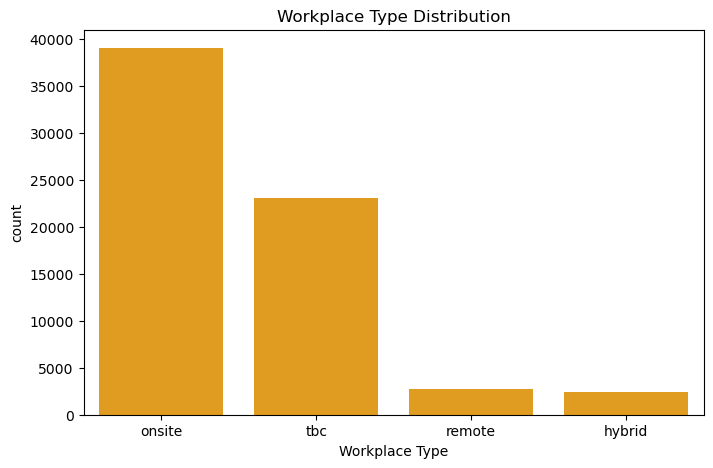

In [137]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='workplace_type', color='orange', order=df['workplace_type'].value_counts().index)
plt.title('Workplace Type Distribution')
plt.xlabel('Workplace Type')
plt.show()

## Findings

This visualization shows the prevalence of remote, hybrid, and on-site opportunities.

A big part of the data is 'To Be Confirmed'

## Geographic Distribution

In [138]:
top_countries = df['country'].value_counts().head(10)

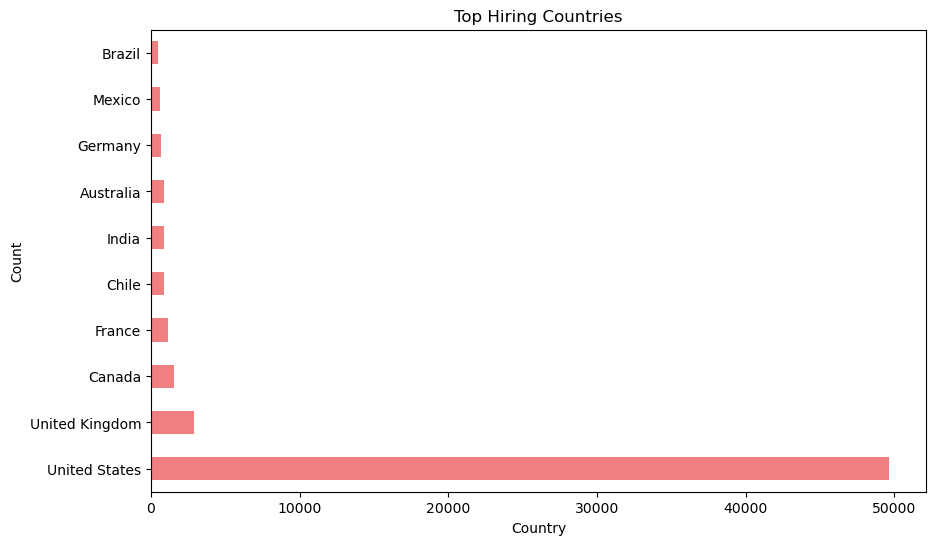

In [139]:
plt.figure(figsize=(10, 6))

top_countries.sort_values(ascending=False).plot(kind='barh', color='lightcoral')
plt.title('Top Hiring Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

## Job Freashness

Measure how recently jobs were posted.

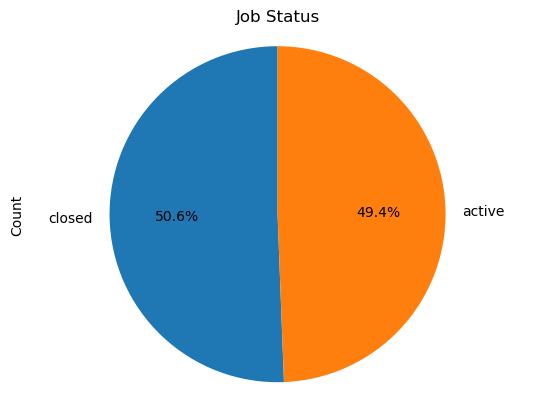

In [140]:
status_counts = df['status'].value_counts()
status_counts.plot(kind="pie", autopct='%1.1f%%', startangle=90)
plt.ylabel('Count')
plt.title('Job Status')
plt.axis('equal')
plt.show() 

In [141]:
now = pd.Timestamp.now(tz="UTC")
days_since_posted = (now - df['posted_at']).dt.days

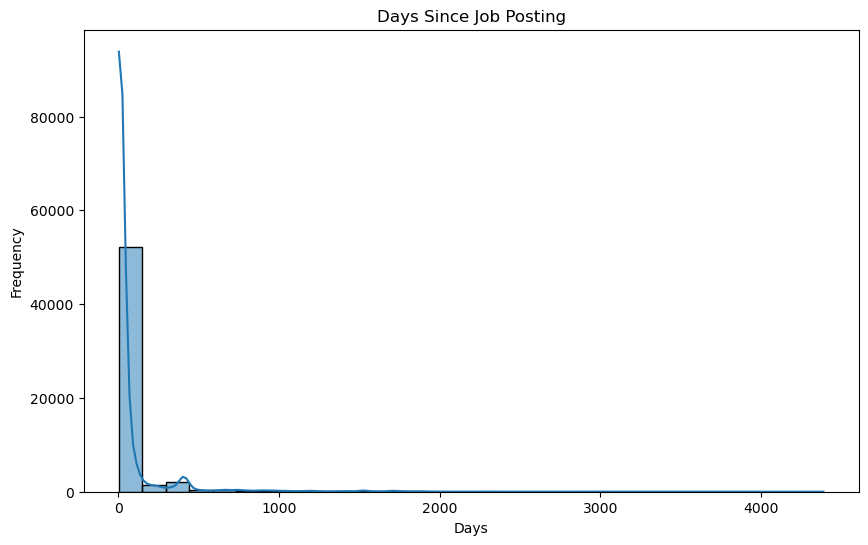

In [142]:
plt.figure(figsize=(10, 6))

sns.histplot(data=days_since_posted, bins=30, kde=True)
plt.title('Days Since Job Posting')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

## Predictions

In [143]:
# daily job postings

daily_jobs = df.groupby(df['posted_at'].dt.date).size().reset_index()
daily_jobs.columns = ['date', 'job_count']
daily_jobs['date'] = pd.to_datetime(daily_jobs['date'])
daily_jobs = daily_jobs.sort_values('date')

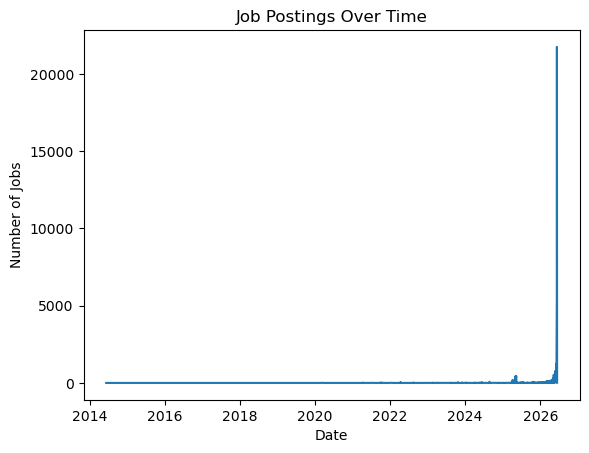

In [144]:
plt.plot(daily_jobs['date'], daily_jobs['job_count'])
plt.title("Job Postings Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Jobs")
plt.show()

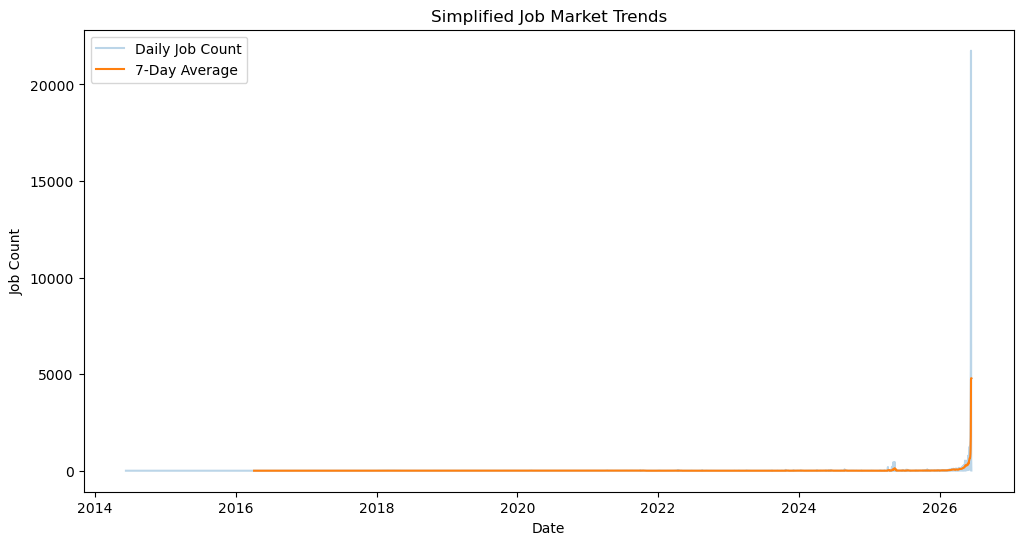

In [154]:
daily_jobs['rolling_7'] = daily_jobs['job_count'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(daily_jobs['date'], daily_jobs['job_count'], alpha=0.3, label='Daily Job Count')
plt.plot(daily_jobs['date'], daily_jobs['rolling_7'], label='7-Day Average')
plt.xlabel('Date')
plt.ylabel('Job Count')
plt.title('Simplified Job Market Trends')
plt.legend()
plt.show()

22:30:51 - cmdstanpy - INFO - Chain [1] start processing
22:30:51 - cmdstanpy - INFO - Chain [1] done processing


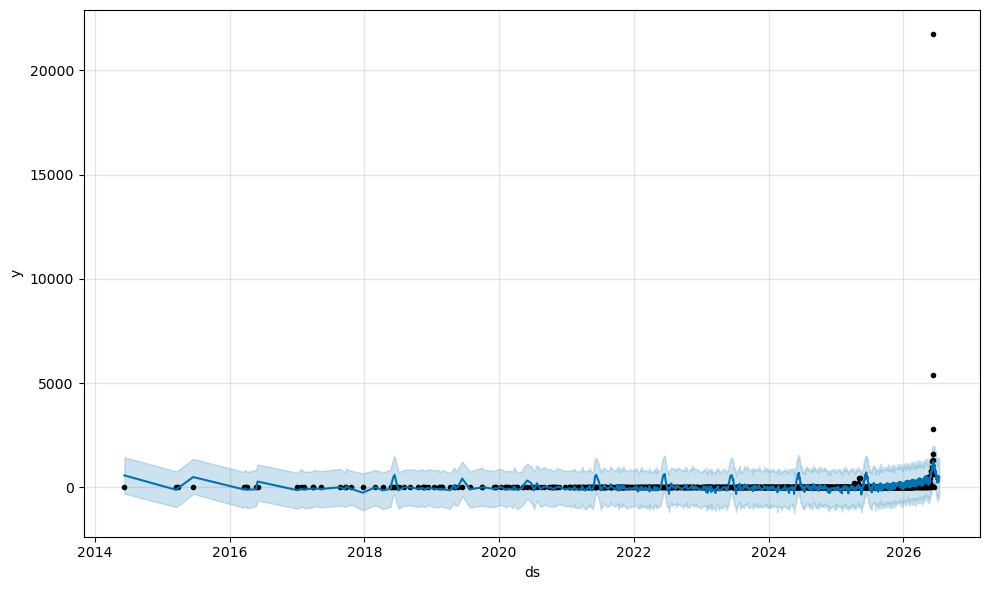

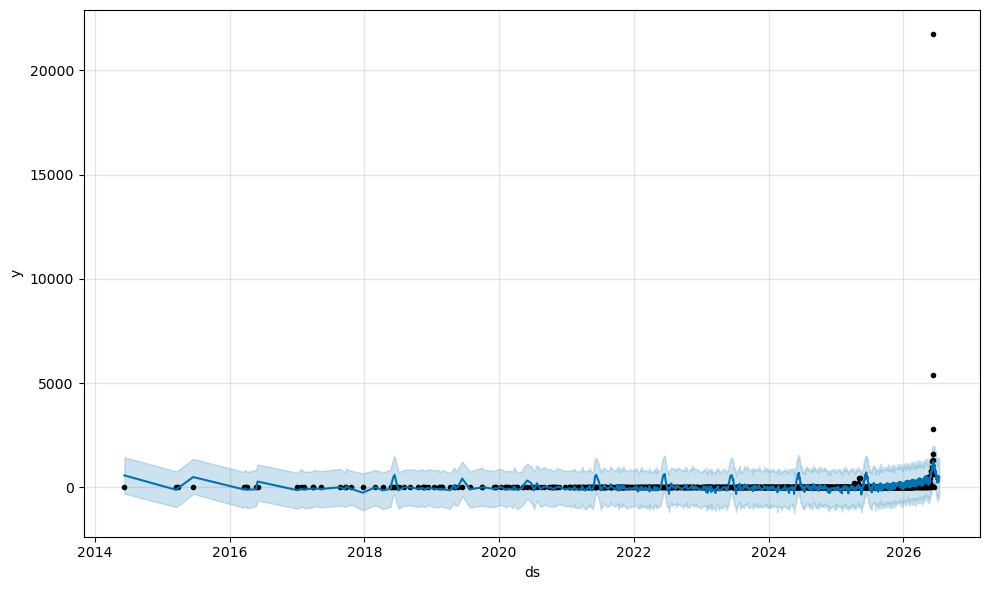

In [155]:
from prophet import Prophet

prophet_df = daily_jobs.rename(columns={
    'date': 'ds',
    'job_count': 'y'
})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)


# Conclusion

## Key Findings

1. Identified the most frequently posted job titles and hiring roles  
2. Analyzed department-level hiring distribution  
3. Examined remote, hybrid, and on-site work trends  
4. Explored geographic hiring patterns across regions  
5. Observed time-based hiring trends and seasonality patterns  
6. Measured job posting freshness and activity levels  
7. Forecasted future job posting trends using time-series modeling (Prophet)  

---

## Final Insights

The analysis shows that job postings are not evenly distributed over time or across roles. Hiring activity fluctuates, suggesting seasonal and demand-driven patterns in the job market.

Time-series forecasting using Prophet provided a structured way to model these trends and project future posting activity.

---

## Tools Used

- Python  
- Pandas  
- Matplotlib  
- Seaborn  
- Prophet  

---

## Skills Demonstrated

- Data Cleaning  
- Exploratory Data Analysis (EDA)  
- Feature Engineering  
- Data Visualization  
- Time-Series Forecasting  
- Insight Generation from Real-World Data  